In [2]:
# Imports
from nltk.corpus import movie_reviews
import random
import pandas as pd
from collections import Counter
from math import log
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, WordPunctTokenizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem import WordNetLemmatizer
import nltk
import numpy as np
from nltk.classify import NaiveBayesClassifier
from nltk.classify import accuracy
from transformers import pipeline
from datasets import load_dataset
import google.generativeai as genai
import time
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')   
nltk.download("omw-1.4")
nltk.download("punkt_tab")

from sklearn.model_selection import train_test_split


C:\Users\kopil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kopil\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kopil\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kopil\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\kopil\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package 

In [3]:
df = pd.read_csv('final_results_long_format.csv')

In [4]:
df.head()

,source,question,answer,writer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers


In [5]:
df['question_clean'] = (
    df['question']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['question_clean'] = df['question_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [6]:
df['answer_clean'] = (
    df['answer']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['answer_clean'] = df['answer_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [7]:
df['answer_clean'].head(20)

0     Imagine you have a toy train. Some toy trains ...
1     In conjunction with the software , the IR sens...
2     The authorities in the case would have gathere...
3     Emulators are programs that allow a computer t...
4     In the US , pretty much all blacks originally ...
5     Imagine you have a box with a toy inside. You ...
6     The car dealership doesn't care where you get ...
7     Judging market efficiency solely from raw pric...
8     Imagine you're eating a candy. Some candies ar...
9     Martial arts can be effective in a street figh...
10    To continue your scholarships , generally . Mo...
11    Easter is a holiday that celebrates the resurr...
12    Isopropyl alcohol is a type of alcohol that ca...
13    All parties in WWII engaged in extensive bombi...
14    Hiroshima and Nagasaki are both densely popula...
15    Chemotherapy is a poison designed to kill fast...
16    Imagine you're swinging a ball on a string aro...
17    In Japanese, it is common to add certain w

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['answer'])
tfidf_scores = tfidf_matrix.mean(axis=1)

In [9]:
df.head()

,source,question,answer,writer,question_clean,answer_clean
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens..."
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ..."


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

question_vecs = vectorizer.fit_transform(df['question'])
answer_vecs = vectorizer.transform(df['answer_clean'])

df['cosine_sim'] = [
    cosine_similarity(question_vecs[i], answer_vecs[i])[0][0]
    for i in range(len(df))
]

In [11]:
df.head()

,source,question,answer,writer,question_clean,answer_clean,cosine_sim
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains ...,0.217907
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers,How does Nintendo 's labo work ? I just do n't...,"In conjunction with the software , the IR sens...",0.019483
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers,How do they know the Chechens being hunted dow...,The authorities in the case would have gathere...,0.083611
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,How are emulators written ? I only have very b...,Emulators are programs that allow a computer t...,0.142301
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers,"Affirmative action . Thanks , I 'm not america...","In the US , pretty much all blacks originally ...",0.126231


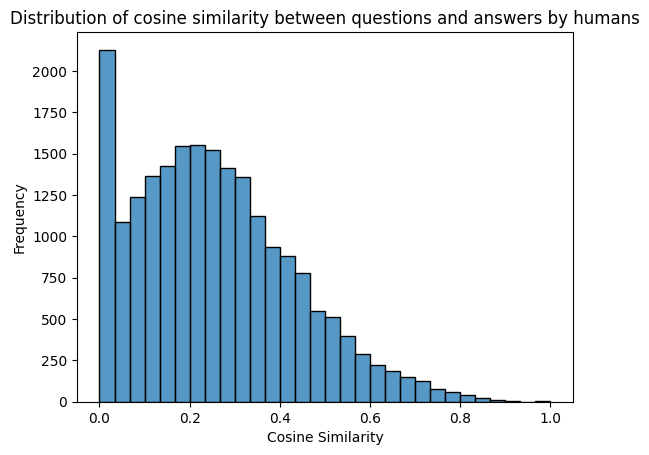

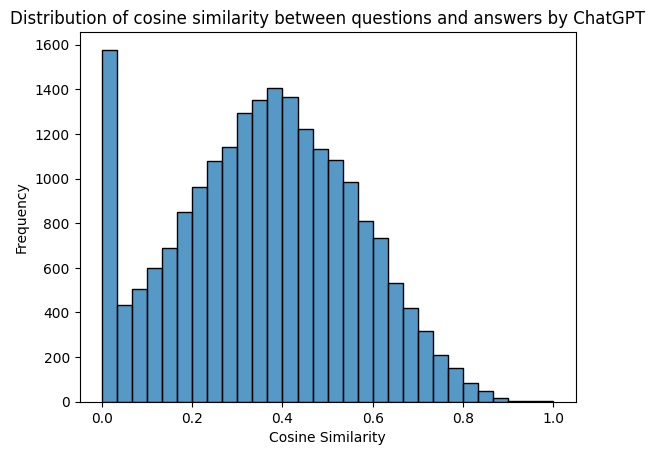

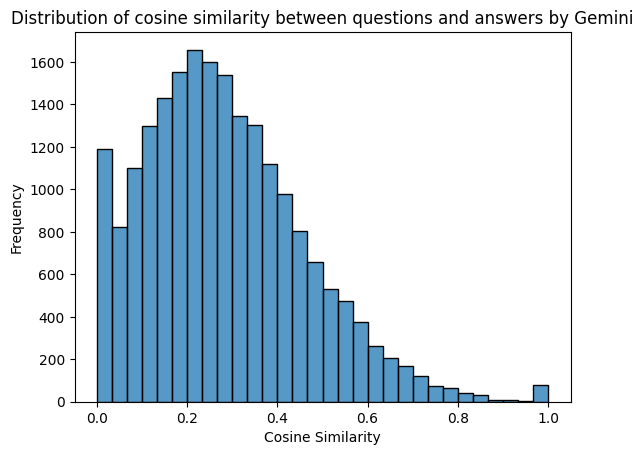

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.histplot(data = df[df['writer'] == 'human_answers'], x = 'cosine_sim', bins=30, label='Human Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by humans')
plt.show()

sns.histplot(data = df[df['writer'] == 'chatgpt_answers'], x = 'cosine_sim', bins=30, label='ChatGPT Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by ChatGPT')
plt.show()

sns.histplot(data = df[df['writer'] == 'answer_gemini'], x = 'cosine_sim', bins=30, label='Gemini Answers')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by Gemini')
plt.show()

In [13]:
df = df[
    [
        
        'answer_clean',
        'cosine_sim',
        'source',
        'question',
        'writer',
        'answer'
    ]
]
df.head(1)

,answer_clean,cosine_sim,source,question,writer,answer
0,Imagine you have a toy train. Some toy trains ...,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...


In [14]:
df_human_answers = df[df['writer'] == 'human_answers'].copy()
df_gpt_answers = df[df['writer'] == 'chatgpt_answers'].copy()
df_gemini_answers = df[df['writer'] == 'answer_gemini'].copy()

df_human_answers.loc[:, 'answer_symbols_only'] = df_human_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)
df_gpt_answers.loc[:, 'answer_symbols_only'] = df_gpt_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)
df_gemini_answers.loc[:, 'answer_symbols_only'] = df_gemini_answers['answer_clean'].str.replace(r'[A-Za-z0-9\s]', '', regex=True)


In [15]:
from collections import Counter

char_counter_human = Counter()
char_counter_gpt = Counter()
char_counter_gemini = Counter()

for q in df_human_answers['answer_symbols_only']:
    char_counter_human.update(q)

for q in df_gpt_answers['answer_symbols_only']:
    char_counter_gpt.update(q)

for q in df_gemini_answers['answer_symbols_only']:
    char_counter_gemini.update(q)

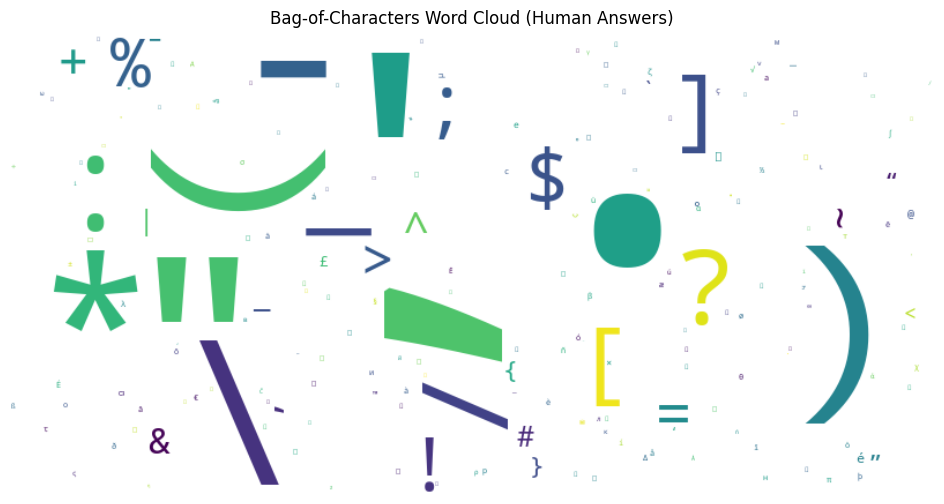

In [16]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_human)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (Human Answers)")
plt.show()

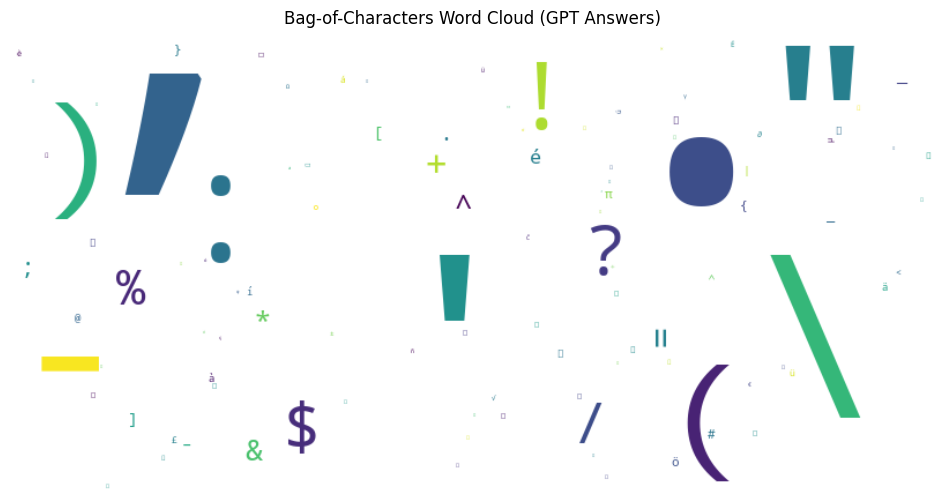

In [17]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_gpt)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (GPT Answers)")
plt.show()

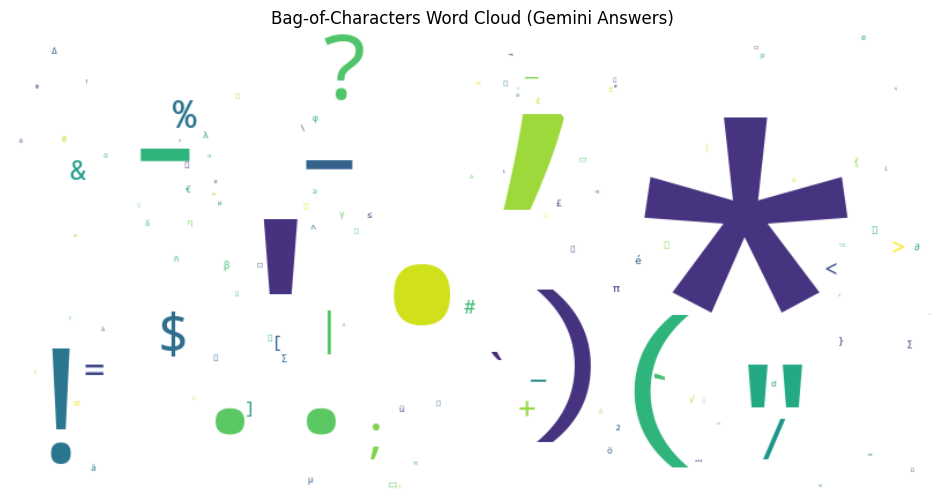

In [18]:
from wordcloud import WordCloud
char_counter_gemini.most_common(20)
wc = WordCloud(width=800, height=400, background_color='white')
wc.generate_from_frequencies(char_counter_gemini)
plt.figure(figsize=(15, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Bag-of-Characters Word Cloud (Gemini Answers)")
plt.show()

In [19]:
df.head()

,answer_clean,cosine_sim,source,question,writer,answer
0,Imagine you have a toy train. Some toy trains ...,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...
1,"In conjunction with the software , the IR sens...",0.019483,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,human_answers,"['In conjunction with the software , the IR se..."
2,The authorities in the case would have gathere...,0.083611,reddit_eli5,How do they know the Chechens being hunted dow...,chatgpt_answers,['The authorities in the case would have gathe...
3,Emulators are programs that allow a computer t...,0.142301,reddit_eli5,How are emulators written ? I only have very b...,chatgpt_answers,['Emulators are programs that allow a computer...
4,"In the US , pretty much all blacks originally ...",0.126231,reddit_eli5,"Affirmative action . Thanks , I 'm not america...",human_answers,"['In the US , pretty much all blacks originall..."


In [20]:
df['no punct'] = df['answer_clean']
df.drop(columns=['answer_clean'], inplace=True)

In [21]:
df['answer_length'] = df['answer'].apply(lambda x: len(x.split()))
df['question_length'] = df['question'].apply(lambda x: len(x.split()))

In [22]:
df.head()

,cosine_sim,source,question,writer,answer,no punct,answer_length,question_length
0,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...,Imagine you have a toy train. Some toy trains ...,150,23
1,0.019483,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,human_answers,"['In conjunction with the software , the IR se...","In conjunction with the software , the IR sens...",498,38
2,0.083611,reddit_eli5,How do they know the Chechens being hunted dow...,chatgpt_answers,['The authorities in the case would have gathe...,The authorities in the case would have gathere...,129,44
3,0.142301,reddit_eli5,How are emulators written ? I only have very b...,chatgpt_answers,['Emulators are programs that allow a computer...,Emulators are programs that allow a computer t...,160,53
4,0.126231,reddit_eli5,"Affirmative action . Thanks , I 'm not america...",human_answers,"['In the US , pretty much all blacks originall...","In the US , pretty much all blacks originally ...",650,24


In [23]:
import string   
def preprocess_text(
    text,
    stopwords,
    lemmatizer,
    stemmer=None
):
    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # remove urls & emails
    text = re.sub(r"https?://\S+|www\.\S+|\S+@\S+", " ", text)

    # remove punctuation & extra spaces
    text = re.sub(f"[{string.punctuation}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)

    # remove stopwords & short tokens
    tokens = [t for t in tokens if t not in stopwords and len(t) > 1]

    # lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # optional stemming
    if stemmer:
        tokens = [stemmer.stem(t) for t in tokens]

    return " ".join(tokens)


In [24]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_answer(text):
    return preprocess_text(
        text,
        stopwords=stop_words,
        lemmatizer=lemmatizer
    )

df['cleaned_answer'] = df['answer'].apply(clean_answer)


In [25]:
vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(df['cleaned_answer'])

tfidf_scores = tfidf_matrix.mean(axis=1)

df['tfidf_score'] = np.array(tfidf_scores).flatten()

df.head()


,cosine_sim,source,question,writer,answer,no punct,answer_length,question_length,cleaned_answer,tfidf_score
0,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,0.000076
1,0.019483,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,human_answers,"['In conjunction with the software , the IR se...","In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,0.000122
2,0.083611,reddit_eli5,How do they know the Chechens being hunted dow...,chatgpt_answers,['The authorities in the case would have gathe...,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,0.000074
3,0.142301,reddit_eli5,How are emulators written ? I only have very b...,chatgpt_answers,['Emulators are programs that allow a computer...,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,0.000069
4,0.126231,reddit_eli5,"Affirmative action . Thanks , I 'm not america...",human_answers,"['In the US , pretty much all blacks originall...","In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,0.000124


In [26]:
df.groupby('writer')['answer_length'].mean().reset_index()

,writer,answer_length
0,answer_gemini,203.964260
1,chatgpt_answers,186.048476
2,human_answers,350.887667


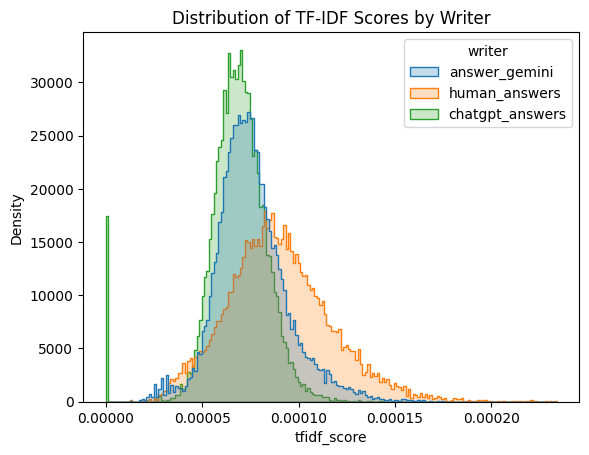

In [27]:
sns.histplot(data=df, x='tfidf_score', hue='writer', element='step', stat='density', common_norm=False)
plt.title('Distribution of TF-IDF Scores by Writer')
plt.show()


In [28]:
from collections import Counter
Counter(df['tfidf_score'])

Counter({0.0: 455,
         3.906331557092952e-05: 13,
         1.3226638449837974e-05: 7,
         2.821760287487849e-05: 7,
         0.00011391014800740543: 6,
         0.00011051710854912227: 6,
         2.825676469724927e-05: 6,
         2.4969655855240096e-05: 5,
         0.00010752763952727565: 4,
         9.553876825836942e-05: 4,
         9.662413785429864e-05: 4,
         3.630344725150606e-05: 3,
         7.163502907668095e-05: 3,
         5.585860671975123e-05: 3,
         0.00010915485148136718: 3,
         0.00012802926890753216: 3,
         5.649431329423367e-05: 3,
         8.629440961693743e-05: 3,
         8.435527450373181e-05: 2,
         9.952090480652088e-05: 2,
         0.00012719610899036208: 2,
         6.113468987135969e-05: 2,
         5.59356871917033e-05: 2,
         7.96344509047027e-05: 2,
         6.0442169004004674e-05: 2,
         8.473228291145968e-05: 2,
         5.386969126253942e-05: 2,
         8.470441463043712e-05: 2,
         6.773086493593989e-

In [29]:
df['answer_length'].nunique()

1509

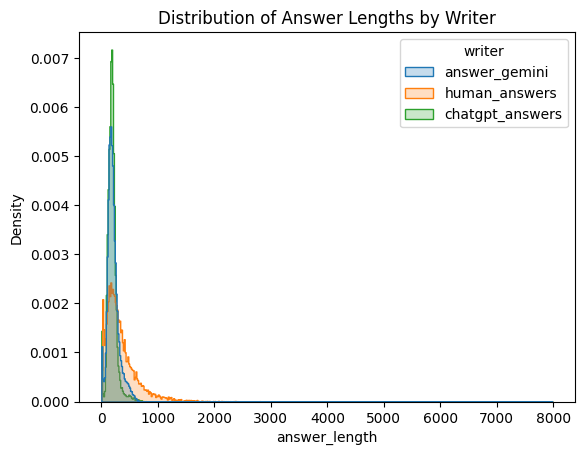

In [30]:
sns.histplot(data=df, x='answer_length', hue='writer', element='step', stat='density', common_norm=False)
plt.title('Distribution of Answer Lengths by Writer')
plt.show()

In [31]:
Counter(df['answer_length'])

Counter({1: 457,
         183: 340,
         174: 332,
         159: 332,
         162: 328,
         169: 328,
         173: 327,
         182: 327,
         171: 325,
         193: 323,
         168: 321,
         186: 319,
         172: 318,
         188: 317,
         170: 316,
         167: 316,
         163: 313,
         179: 312,
         176: 311,
         156: 310,
         185: 309,
         160: 308,
         177: 307,
         151: 306,
         175: 306,
         181: 305,
         194: 304,
         148: 303,
         180: 302,
         204: 302,
         191: 299,
         178: 297,
         187: 297,
         150: 296,
         154: 296,
         192: 295,
         158: 294,
         143: 294,
         164: 293,
         142: 293,
         195: 293,
         152: 291,
         149: 290,
         203: 290,
         157: 290,
         140: 290,
         165: 289,
         189: 289,
         198: 287,
         144: 286,
         197: 285,
         196: 285,
         153: 

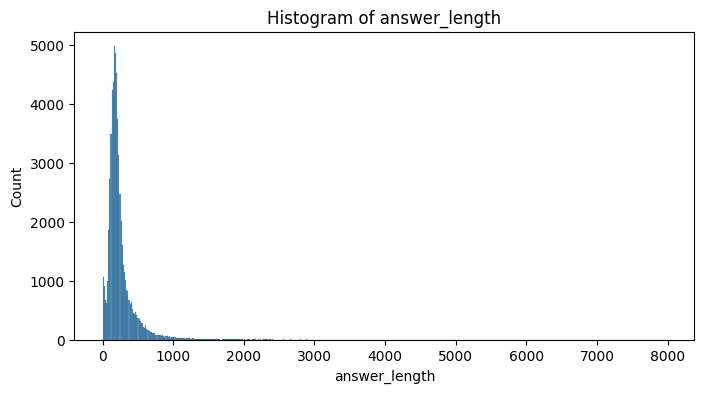

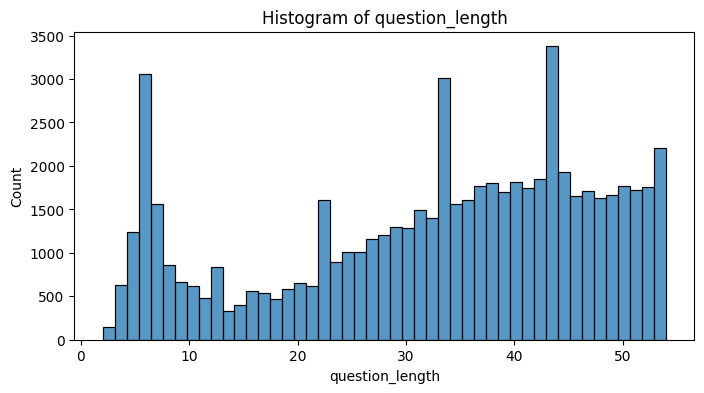

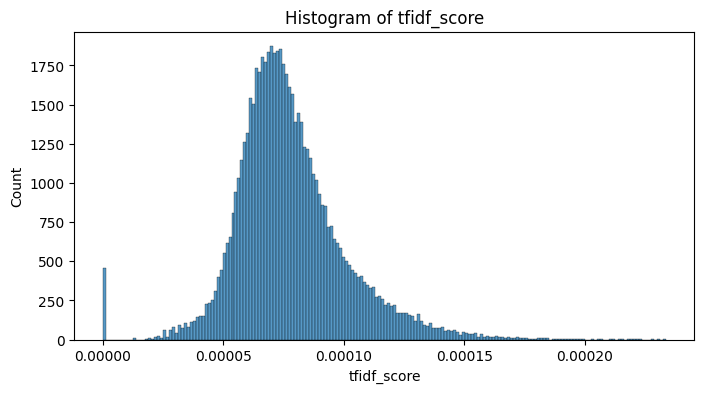

In [32]:
for column in df.loc[:, ['answer_length', 'question_length', 'tfidf_score']]:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=column, data=df)
    plt.title(f'Histogram of {column}')
    plt.show()

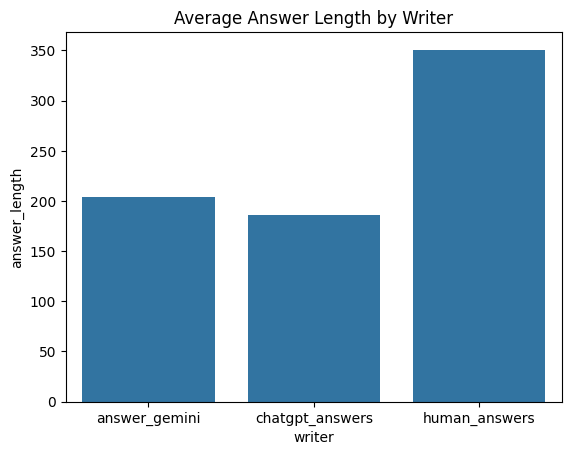

In [33]:
average_answer_len_each_writer = df.groupby('writer')['answer_length'].mean().reset_index()
graph = sns.barplot(x='writer', y='answer_length', data=average_answer_len_each_writer)
plt.title('Average Answer Length by Writer')
plt.show()


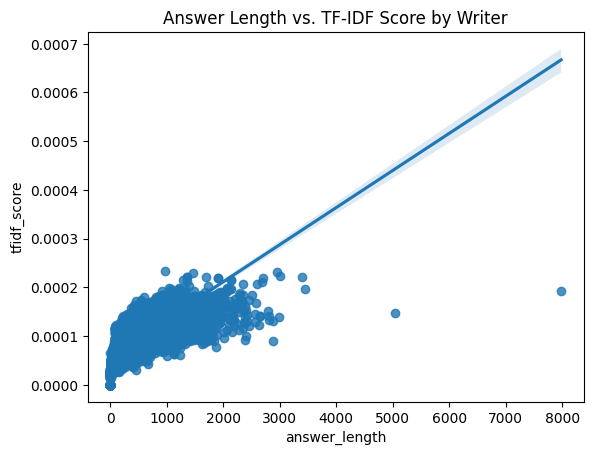

In [34]:
sns.regplot(data=df, x='answer_length', y='tfidf_score')
plt.title('Answer Length vs. TF-IDF Score by Writer')  
plt.show()

In [35]:
df.head()

,cosine_sim,source,question,writer,answer,no punct,answer_length,question_length,cleaned_answer,tfidf_score
0,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,0.000076
1,0.019483,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,human_answers,"['In conjunction with the software , the IR se...","In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,0.000122
2,0.083611,reddit_eli5,How do they know the Chechens being hunted dow...,chatgpt_answers,['The authorities in the case would have gathe...,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,0.000074
3,0.142301,reddit_eli5,How are emulators written ? I only have very b...,chatgpt_answers,['Emulators are programs that allow a computer...,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,0.000069
4,0.126231,reddit_eli5,"Affirmative action . Thanks , I 'm not america...",human_answers,"['In the US , pretty much all blacks originall...","In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,0.000124


In [36]:
texts = df['answer'].tolist()
vectorizer = TfidfVectorizer(stop_words='english')
vec = vectorizer.fit(texts)

In [37]:
tfidf_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4207700 stored elements and shape (62845, 75605)>

In [38]:
df['tfidf_vectorizer'] =df['answer'].apply(lambda x: vec.transform([x]))

In [39]:
df['tfidf_vectorizer'].head()

0    <Compressed Sparse Row sparse matrix of dtype ...
1    <Compressed Sparse Row sparse matrix of dtype ...
2    <Compressed Sparse Row sparse matrix of dtype ...
3    <Compressed Sparse Row sparse matrix of dtype ...
4    <Compressed Sparse Row sparse matrix of dtype ...
Name: tfidf_vectorizer, dtype: object

In [40]:
X = vectorizer.fit_transform(df["cleaned_answer"])

classes = df["writer"].unique()
centroids = {}

for c in classes:
    mask = (df["writer"].values == c)
    centroids[c] = X[mask].mean(axis=0)   


In [41]:
centroids

{'answer_gemini': matrix([[1.67032705e-04, 1.12001948e-03, 3.06920368e-05, ...,
          0.00000000e+00, 1.01697426e-05, 0.00000000e+00]],
        shape=(1, 75605)),
 'human_answers': matrix([[7.05168435e-04, 4.42623472e-03, 6.27927595e-05, ...,
          6.54086455e-06, 5.37702802e-06, 7.67360774e-06]],
        shape=(1, 75605)),
 'chatgpt_answers': matrix([[2.80217704e-04, 1.55891788e-03, 2.58890712e-05, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],
        shape=(1, 75605))}

In [42]:
from scipy.sparse import vstack, csr_matrix
from sklearn.metrics.pairwise import cosine_similarity

# X is your TF-IDF matrix: X = vectorizer.fit_transform(df["cleaned_answer"])
# centroids is dict: centroids[c] = X[mask].mean(axis=0)

classes = list(centroids.keys())

# Stack centroids into a matrix: (n_classes, n_features)
C = vstack([csr_matrix(centroids[c]) for c in classes]).tocsr()

# Cosine similarity: (n_rows, n_classes)
S = cosine_similarity(X, C)   # works with sparse matrices

# Save to df
for j, c in enumerate(classes):
    df[f"cos_to_{c}"] = S[:, j]

df["pred_writer"] = [classes[i] for i in S.argmax(axis=1)]
df["pred_score"] = S.max(axis=1)


In [43]:
df.head()

,cosine_sim,source,question,writer,answer,no punct,answer_length,question_length,cleaned_answer,tfidf_score,tfidf_vectorizer,cos_to_answer_gemini,cos_to_human_answers,cos_to_chatgpt_answers,pred_writer,pred_score
0,0.217907,reddit_eli5,Why do some animals become trained more easily...,answer_gemini,Imagine you have a toy train. Some toy trains...,Imagine you have a toy train. Some toy trains ...,150,23,imagine toy train toy train built follow track...,0.000076,<Compressed Sparse Row sparse matrix of dtype ...,0.223619,0.134160,0.132219,answer_gemini,0.223619
1,0.019483,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,human_answers,"['In conjunction with the software , the IR se...","In conjunction with the software , the IR sens...",498,38,conjunction software ir sensor right joy con a...,0.000122,<Compressed Sparse Row sparse matrix of dtype ...,0.104562,0.121780,0.095460,human_answers,0.121780
2,0.083611,reddit_eli5,How do they know the Chechens being hunted dow...,chatgpt_answers,['The authorities in the case would have gathe...,The authorities in the case would have gathere...,129,44,authority case would gathered evidence informa...,0.000074,<Compressed Sparse Row sparse matrix of dtype ...,0.038772,0.068103,0.089330,chatgpt_answers,0.089330
3,0.142301,reddit_eli5,How are emulators written ? I only have very b...,chatgpt_answers,['Emulators are programs that allow a computer...,Emulators are programs that allow a computer t...,160,53,emulator program allow computer imitate functi...,0.000069,<Compressed Sparse Row sparse matrix of dtype ...,0.064589,0.094798,0.140516,chatgpt_answers,0.140516
4,0.126231,reddit_eli5,"Affirmative action . Thanks , I 'm not america...",human_answers,"['In the US , pretty much all blacks originall...","In the US , pretty much all blacks originally ...",650,24,u pretty much black originally arrived slave u...,0.000124,<Compressed Sparse Row sparse matrix of dtype ...,0.097590,0.164052,0.153385,human_answers,0.164052


In [44]:
# import decsion tree model
from sklearn.tree import DecisionTreeClassifier

In [46]:
df.columns

Index(['cosine_sim', 'source', 'question', 'writer', 'answer', 'no punct',
       'answer_length', 'question_length', 'cleaned_answer', 'tfidf_score',
       'tfidf_vectorizer', 'cos_to_answer_gemini', 'cos_to_human_answers',
       'cos_to_chatgpt_answers', 'pred_writer', 'pred_score'],
      dtype='object')

In [47]:
df_for_tree = df[['cosine_sim','writer','answer_length','tfidf_score','cos_to_answer_gemini', 'cos_to_human_answers','cos_to_chatgpt_answers']]

In [48]:
X = df_for_tree.drop('writer', axis=1)
y = df_for_tree['writer']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[3695  264  260]
 [ 228 3601  309]
 [ 267  304 3641]]
                 precision    recall  f1-score   support

  answer_gemini       0.88      0.88      0.88      4219
chatgpt_answers       0.86      0.87      0.87      4138
  human_answers       0.86      0.86      0.86      4212

       accuracy                           0.87     12569
      macro avg       0.87      0.87      0.87     12569
   weighted avg       0.87      0.87      0.87     12569



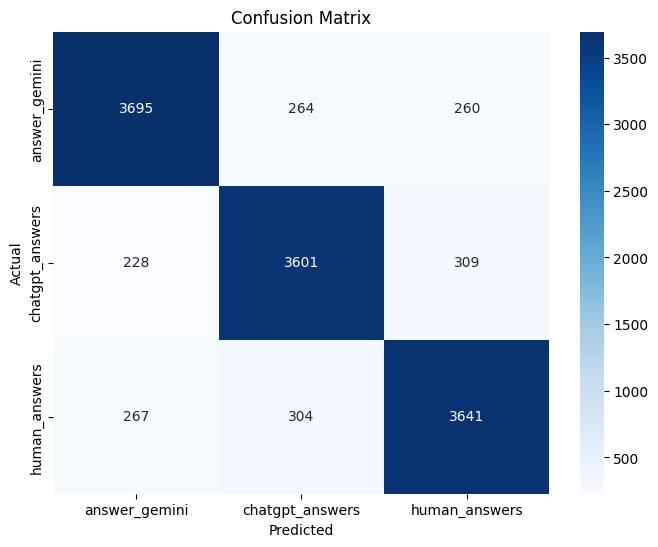

In [50]:
#display confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


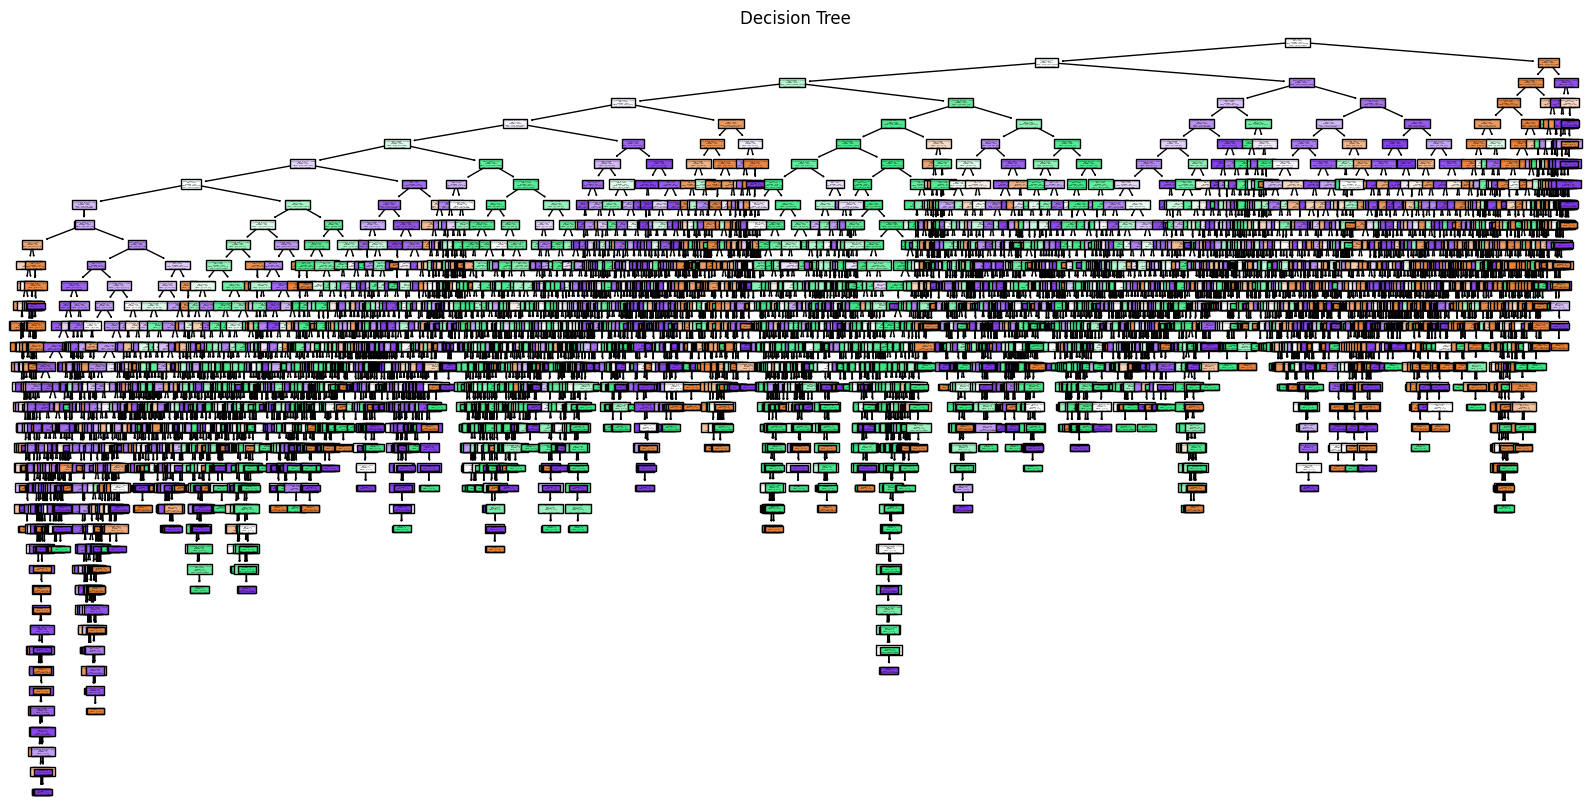

In [51]:
#display decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True)
plt.title('Decision Tree')
plt.show()
